In [2]:
import kagglehub
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Better looking plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
# from scipy.stats import skew, kurtosis, shapiro, probplot

In [3]:
# Download latest version
path = kagglehub.dataset_download("saurabhbadole/zomato-delivery-operations-analytics-dataset")

csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]

print("Dataset downloaded")

Dataset downloaded


In [4]:
#Understnading the dataset
df = pd.read_csv(os.path.join(path, csv_file))

df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [5]:
df.sample(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
5784,0x17f4,HYDRES12DEL01,35.0,4.7,17.429585,78.392621,17.539585,78.502621,08-03-2022,23:35,23:40,Sunny,Low,2,Meal,scooter,1.0,No,Urban,27
43560,0x9f71,PUNERES18DEL01,30.0,4.6,18.593481,73.785901,18.603481,73.795901,01-04-2022,10:25,10:40,Cloudy,Low,1,Snack,scooter,1.0,No,Urban,17
10337,0x378a,MYSRES20DEL02,24.0,4.3,12.337978,76.616792,12.357978,76.636792,07-03-2022,10:15,10:30,Sandstorms,Low,0,Meal,motorcycle,1.0,No,Urban,22
2523,0x5b3,JAPRES02DEL02,NaN,NaN,26.914142,75.805704,27.044142,75.935704,06-03-2022,NaN,1,NaN,NaN,3,Buffet,electric_scooter,1.0,No,Metropolitian,28
43720,0x6816,JAPRES18DEL03,38.0,4.9,26.913987,75.752891,26.943987,75.782891,11-03-2022,21:40,21:55,Fog,Jam,0,Drinks,motorcycle,1.0,No,Metropolitian,26


In [6]:
df.shape

(45584, 20)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Vehicle_conditio

In [8]:
# df.isnull().sum()
(df.isnull().sum()/len(df))*100

ID                             0.000000
Delivery_person_ID             0.000000
Delivery_person_Age            4.067217
Delivery_person_Ratings        4.185679
Restaurant_latitude            0.000000
Restaurant_longitude           0.000000
Delivery_location_latitude     0.000000
Delivery_location_longitude    0.000000
Order_Date                     0.000000
Time_Orderd                    3.797385
Time_Order_picked              0.000000
Weather_conditions             1.351351
Road_traffic_density           1.318445
Vehicle_condition              0.000000
Type_of_order                  0.000000
Type_of_vehicle                0.000000
multiple_deliveries            2.178396
Festival                       0.500176
City                           2.632503
Time_taken (min)               0.000000
dtype: float64

In [9]:
int(df.duplicated().sum())

0

In [10]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken (min)
count,43730.000000,43676.000000,45584.000000,45584.000000,45584.000000,45584.000000,45584.000000,44591.000000,45584.000000
mean,29.566911,4.633774,17.017948,70.229684,17.465480,70.844161,1.023385,0.744635,26.293963
std,5.815064,0.334744,8.185674,22.885575,7.335562,21.120578,0.839055,0.572510,9.384298
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.551440,75.897963,18.633934,76.002574,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


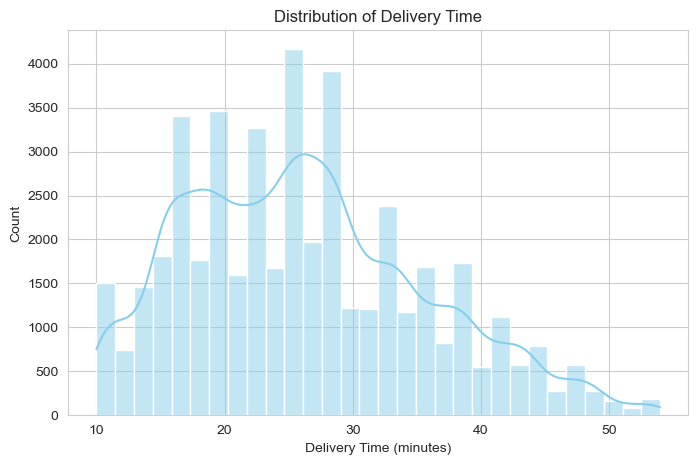

Average Delivery Time: 26.29 minutes
Minimum Delivery Time: 10
Maximum Delivery Time: 54


In [16]:
# Distribution of delivery time

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Time_taken (min)",
    bins=30,
    kde=True,
    color="skyblue"
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Count")

plt.show()

# Average delivery time
print("Average Delivery Time:", round(df["Time_taken (min)"].mean(), 2), "minutes")

# Minimum and maximum values
print("Minimum Delivery Time:", df["Time_taken (min)"].min())
print("Maximum Delivery Time:", df["Time_taken (min)"].max())

In [25]:
# Number of deliveries under 30 minutes
under_30 = (df["Time_taken (min)"] <= 30).sum()

print("Deliveries under 30 minutes:", under_30)

Deliveries under 30 minutes: 31982


In [26]:
total_deliveries = len(df)
percentage = (under_30 / total_deliveries) * 100

print(f"Deliveries under 30 minutes: {under_30}")
print(f"Percentage: {percentage:.2f}%")

Deliveries under 30 minutes: 31982
Percentage: 70.16%


C:\Users\pawan\AppData\Local\Temp\ipykernel_26908\1754041512.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


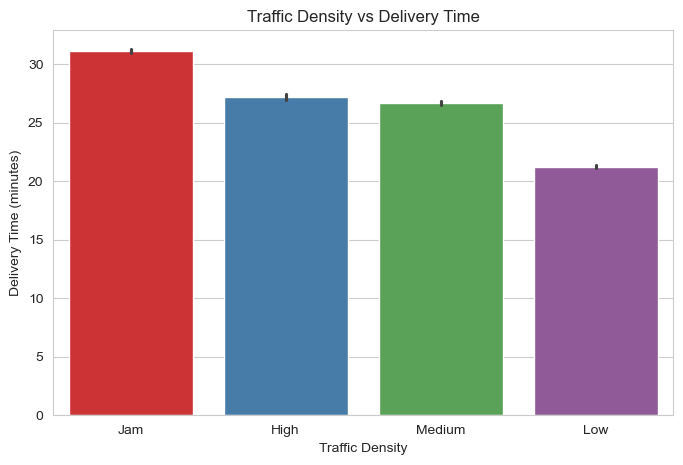

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Road_traffic_density",
    y="Time_taken (min)",
    palette="Set1"
)

plt.title("Traffic Density vs Delivery Time")
plt.xlabel("Traffic Density")
plt.ylabel("Delivery Time (minutes)")

plt.show()

In [23]:
# Define late deliveries
late_deliveries = df[df["Time_taken (min)"] > 30]

# Count late deliveries in each traffic condition
late_counts = late_deliveries["Road_traffic_density"].value_counts()

print("Late deliveries by traffic density:")
print(late_counts)

Late deliveries by traffic density:
Road_traffic_density
Jam       7159
Medium    3554
High      1485
Low       1218
Name: count, dtype: int64


In [35]:
# Remove rows with invalid coordinates
df = df[
    (df["Restaurant_latitude"] > 1) &
    (df["Restaurant_longitude"] > 1) &
    (df["Delivery_location_latitude"] > 1) &
    (df["Delivery_location_longitude"] > 1)
].copy()

# Haversine Formula
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

# Calculate distance
df["distance_km"] = haversine(
    df["Restaurant_latitude"],
    df["Restaurant_longitude"],
    df["Delivery_location_latitude"],
    df["Delivery_location_longitude"]
)

# Remove unrealistic distances (>50 km for food delivery)
df = df[df["distance_km"] <= 50].copy()

# Summary
print(df["distance_km"].head())

print(f"\nAverage Distance: {df['distance_km'].mean():.2f} km")
print(f"Minimum Distance: {df['distance_km'].min():.2f} km")
print(f"Maximum Distance: {df['distance_km'].max():.2f} km")

0    10.280582
1     6.242319
2    13.787860
3     2.930258
4    19.396618
Name: distance_km, dtype: float64

Average Distance: 10.53 km
Minimum Distance: 2.93 km
Maximum Distance: 19.40 km
